# Exploratory Data Analysis — Hospital Length of Stay Prediction

**Dataset:** `host_train.csv` — Hospital admission records  
**Target Variable:** `Stay_Days` — Ordinal length of stay category (0-10 days through 100+ days)  
**Objective:** Systematically explore data quality, distributions, and relationships to prepare for predictive modeling

---

## EDA Workflow

| Step | Method | Purpose |
|------|--------|---------|
| 1 | Data Import & Copy | Load data safely and create working copy |
| 2 | Shape & Info | Understand dataset dimensions and data types |
| 3 | Descriptive Stats | Get summary statistics and identify outliers |
| 4 | Missing Values | Identify and handle null values appropriately |
| 5 | Duplicates | Detect and remove duplicate records |
| 6 | Univariate Analysis | Analyze individual variable distributions |
| 7 | Bivariate Analysis | Explore relationships between variable pairs |
| 8 | Correlation Analysis | Quantify relationships with correlation matrices |
| 9 | Key Insights | Summarize findings and actionable insights |

---


## Step 1: Data Import & Working Copy

We load the raw CSV and immediately create a working copy. The original is preserved as a reference so we can always compare back to the untouched data if any transformation goes wrong.


In [23]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from scipy.stats import shapiro, yeojohnson
import itertools, warnings
warnings.filterwarnings('ignore')

sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (14, 7)
plt.rcParams['font.size'] = 11
pd.set_option('display.max_columns', 25)
pd.set_option('display.width', 130)

# ── Load & copy ──
df_original = pd.read_csv('host_train.csv')
df = df_original.copy()

print(f"✅ Data loaded successfully")
print(f"   Original shape : {df_original.shape}")
print(f"   Working copy   : {df.shape}")
print(f"   Memory usage   : {df.memory_usage(deep=True).sum() / 1024**2:.1f} MB")


✅ Data loaded successfully
   Original shape : (318438, 18)
   Working copy   : (318438, 18)
   Memory usage   : 142.1 MB


---
## Step 2: Shape, Structure & Data Types

Before touching the data we need to understand what we have: how many rows and columns, what each column represents, and whether the stored data types are correct.


### 2.1 Dataset Dimensions & Sample Rows


In [24]:
print("=" * 90)
print("DATASET OVERVIEW")
print("=" * 90)
print(f"\nRows    : {df.shape[0]:,}")
print(f"Columns : {df.shape[1]}")

print("\n── Column Names ──")
for i, col in enumerate(df.columns, 1):
    print(f"  {i:2d}. {col}")

print("\n── First 5 Rows ──")
display(df.head())

print("\n── Last 5 Rows (edge-case check) ──")
display(df.tail())


DATASET OVERVIEW

Rows    : 318,438
Columns : 18

── Column Names ──
   1. case_id
   2. Hospital
   3. Hospital_type
   4. Hospital_city
   5. Hospital_region
   6. Available_Extra_Rooms_in_Hospital
   7. Department
   8. Ward_Type
   9. Ward_Facility
  10. Bed_Grade
  11. patientid
  12. City_Code_Patient
  13. Type of Admission
  14. Illness_Severity
  15. Patient_Visitors
  16. Age
  17. Admission_Deposit
  18. Stay_Days

── First 5 Rows ──


,case_id,Hospital,Hospital_type,Hospital_city,Hospital_region,Available_Extra_Rooms_in_Hospital,Department,Ward_Type,Ward_Facility,Bed_Grade,patientid,City_Code_Patient,Type of Admission,Illness_Severity,Patient_Visitors,Age,Admission_Deposit,Stay_Days
0,1,8,2,3,2,3,radiotherapy,R,F,2.0,31397,7.0,Emergency,Extreme,2,51-60,4911,0-10
1,2,2,2,5,2,2,radiotherapy,S,F,2.0,31397,7.0,Trauma,Extreme,2,51-60,5954,41-50
2,3,10,4,1,0,2,anesthesia,S,E,2.0,31397,7.0,Trauma,Extreme,2,51-60,4745,31-40
3,4,26,1,2,1,2,radiotherapy,R,D,2.0,31397,7.0,Trauma,Extreme,2,51-60,7272,41-50
4,5,26,1,2,1,2,radiotherapy,S,D,2.0,31397,7.0,Trauma,Extreme,2,51-60,5558,41-50



── Last 5 Rows (edge-case check) ──


,case_id,Hospital,Hospital_type,Hospital_city,Hospital_region,Available_Extra_Rooms_in_Hospital,Department,Ward_Type,Ward_Facility,Bed_Grade,patientid,City_Code_Patient,Type of Admission,Illness_Severity,Patient_Visitors,Age,Admission_Deposit,Stay_Days
318433,318434,6,0,6,0,3,radiotherapy,Q,F,4.0,86499,23.0,Emergency,Moderate,3,41-50,4144,Nov-20
318434,318435,24,0,1,0,2,anesthesia,Q,E,4.0,325,8.0,Urgent,Moderate,4,81-90,6699,31-40
318435,318436,7,0,4,0,3,gynecology,R,F,4.0,125235,10.0,Emergency,Minor,3,71-80,4235,Nov-20
318436,318437,11,1,2,1,3,anesthesia,Q,D,3.0,91081,8.0,Trauma,Minor,5,Nov-20,3761,Nov-20
318437,318438,19,0,7,1,5,gynecology,Q,C,2.0,21641,8.0,Emergency,Minor,2,Nov-20,4752,0-10


**Observation:** The last rows show values like `Nov-20` in both the `Age` and `Stay_Days` columns. This is a well-known Excel auto-format issue — the text `11-20` was misinterpreted as a date (November 20). We will fix this in Section 2.3.


### 2.2 Column Data Dictionary

Each column is described below with its expected type and a basic validation rule. This serves as the reference for all downstream analysis.


In [25]:
print("=" * 90)
print("COLUMN DATA DICTIONARY")
print("=" * 90)

data_dict = {
    'case_id':       ('Unique admission identifier',      'Identifier (int)',      'Must be unique across all rows'),
    'Hospital':      ('Hospital code',                     'Categorical (int)',     'Coded set — 32 unique hospitals'),
    'Hospital_type': ('Hospital category code',            'Categorical (int)',     'Small set: values 0–6 (7 types)'),
    'Hospital_city': ('City code of the hospital',         'Categorical (int)',     'Small set: values 0–10 (11 cities)'),
    'Hospital_region':('Region code of the hospital',      'Categorical (int)',     'Small set: values 0–2 (3 regions)'),
    'Available_Extra_Rooms_in_Hospital': ('Spare room count','Numeric (int)',       'Non-negative integer'),
    'Department':    ('Medical department name',            'Categorical (str)',     'Limited labels: gynecology, radiotherapy, etc.'),
    'Ward_Type':     ('Ward classification letter',         'Categorical (str)',     'Single letters: P, Q, R, S, T, U'),
    'Ward_Facility': ('Facility grade within the ward',     'Categorical (str)',     'Single letters: A–F'),
    'Bed_Grade':     ('Bed quality grade (1–4)',            'Categorical (float→int)','Values in {1, 2, 3, 4}; float due to NaN'),
    'patientid':     ('Patient identifier',                 'Identifier (int)',      'NOT unique — one patient, many admissions'),
    'City_Code_Patient':('City code of patient residence',  'Categorical (float→int)','Coded city; float due to NaN'),
    'Type of Admission':('Route of admission',              'Categorical (str)',     'Values: Emergency, Trauma, Urgent'),
    'Illness_Severity': ('Clinical severity level',         'Categorical (str)',     'Ordinal: Minor < Moderate < Extreme'),
    'Patient_Visitors':  ('Visitor count for this admission','Numeric (int)',        'Non-negative integer'),
    'Age':           ('Patient age bracket',                'Categorical (str)',     '10-year ranges: 0-10, 11-20, …, 91-100'),
    'Admission_Deposit':('Financial deposit at admission',  'Numeric (int)',        'Positive integer (currency)'),
    'Stay_Days':     ('TARGET — length of stay bracket',    'Categorical (str)',     'Ordinal: 0-10, 11-20, …, More than 100 Days'),
}

print(f"\n{'Column':<38} {'Description':<35} {'Expected Type':<24} {'Validation Rule'}")
print("─" * 135)
for col, (desc, etype, rule) in data_dict.items():
    print(f"{col:<38} {desc:<35} {etype:<24} {rule}")


COLUMN DATA DICTIONARY

Column                                 Description                         Expected Type            Validation Rule
───────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
case_id                                Unique admission identifier         Identifier (int)         Must be unique across all rows
Hospital                               Hospital code                       Categorical (int)        Coded set — 32 unique hospitals
Hospital_type                          Hospital category code              Categorical (int)        Small set: values 0–6 (7 types)
Hospital_city                          City code of the hospital           Categorical (int)        Small set: values 0–10 (11 cities)
Hospital_region                        Region code of the hospital         Categorical (int)        Small set: values 0–2 (3 regions)
Available_Extra_Rooms_in_Hospital      Spare room count     

### 2.3 Data Type Audit & Corrections


In [26]:
print("=" * 90)
print("DATA TYPE AUDIT")
print("=" * 90)

print("\n── Current pandas dtypes ──")
df.info()

print("\n\n── Identified Type Mismatches ──")
type_issues = [
    ("Bed_Grade",          "float64", "Categorical int {1,2,3,4}. Float because NaN forced upcast."),
    ("City_Code_Patient",  "float64", "Categorical int (city code). Float because NaN forced upcast."),
    ("Hospital",           "int64",   "Represents a CATEGORY, not a measurement — treat as categorical."),
    ("Hospital_type",      "int64",   "Category code (7 types) — treat as categorical."),
    ("Hospital_city",      "int64",   "Category code (11 cities) — treat as categorical."),
    ("Hospital_region",    "int64",   "Category code (3 regions) — treat as categorical."),
    ("Age",                "object",  "Contains 'Nov-20' — Excel date bug for '11-20'. Must fix."),
    ("Stay_Days",          "object",  "Contains 'Nov-20' — Excel date bug for '11-20'. Must fix."),
]

print(f"\n{'Column':<25} {'Current':<12} {'Issue & Correction'}")
print("─" * 100)
for col, dtype, issue in type_issues:
    print(f"{col:<25} {dtype:<12} {issue}")

# ── Fix Excel date corruption ──
print("\n\n── Applying Fixes ──")
for col in ['Age', 'Stay_Days']:
    corrupted = df[col].value_counts().get('Nov-20', 0)
    df[col] = df[col].str.replace('Nov', '11', regex=False)
    print(f"  {col}: {corrupted:,} corrupted 'Nov-20' entries → fixed to '11-20'")

print(f"\n  Age values after fix    : {sorted(df['Age'].unique())}")
print(f"  Stay_Days values after fix: {sorted(df['Stay_Days'].unique())}")
print("\n✅ All type issues documented and critical fixes applied.")


DATA TYPE AUDIT

── Current pandas dtypes ──
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 318438 entries, 0 to 318437
Data columns (total 18 columns):
 #   Column                             Non-Null Count   Dtype  
---  ------                             --------------   -----  
 0   case_id                            318438 non-null  int64  
 1   Hospital                           318438 non-null  int64  
 2   Hospital_type                      318438 non-null  int64  
 3   Hospital_city                      318438 non-null  int64  
 4   Hospital_region                    318438 non-null  int64  
 5   Available_Extra_Rooms_in_Hospital  318438 non-null  int64  
 6   Department                         318438 non-null  object 
 7   Ward_Type                          318438 non-null  object 
 8   Ward_Facility                      318438 non-null  object 
 9   Bed_Grade                          318325 non-null  float64
 10  patientid                          318438 non-null  int64  

---
## Step 3: Descriptive Statistics

Summary statistics for numeric columns reveal central tendency, spread, and potential issues like impossible values or extreme skew.


In [27]:
# ── Define analysis groups ──
id_cols = ['case_id', 'patientid']

numeric_cols = ['Available_Extra_Rooms_in_Hospital', 'Patient_Visitors', 'Admission_Deposit']

categorical_cols = ['Hospital', 'Hospital_type', 'Hospital_city', 'Hospital_region',
                    'Department', 'Ward_Type', 'Ward_Facility', 'Bed_Grade',
                    'City_Code_Patient', 'Type of Admission', 'Illness_Severity', 'Age', 'Stay_Days']

print(f"Identifiers (excluded from analysis): {id_cols}")
print(f"Numeric features  ({len(numeric_cols)}): {numeric_cols}")
print(f"Categorical features ({len(categorical_cols)}): {categorical_cols}")


Identifiers (excluded from analysis): ['case_id', 'patientid']
Numeric features  (3): ['Available_Extra_Rooms_in_Hospital', 'Patient_Visitors', 'Admission_Deposit']
Categorical features (13): ['Hospital', 'Hospital_type', 'Hospital_city', 'Hospital_region', 'Department', 'Ward_Type', 'Ward_Facility', 'Bed_Grade', 'City_Code_Patient', 'Type of Admission', 'Illness_Severity', 'Age', 'Stay_Days']


In [28]:
print("=" * 90)
print("DESCRIPTIVE STATISTICS — NUMERIC COLUMNS")
print("=" * 90)

stats_table = df[numeric_cols].describe().T
stats_table['median'] = df[numeric_cols].median()
stats_table['skew'] = df[numeric_cols].skew().round(3)
stats_table['kurtosis'] = df[numeric_cols].kurtosis().round(3)
stats_table = stats_table[['count','mean','median','std','min','25%','50%','75%','max','skew','kurtosis']]
print("\n" + stats_table.round(2).to_string())

print("\n\n── Shape Interpretation ──")
for col in numeric_cols:
    sk = df[col].skew()
    shape = "right-skewed ↗" if sk > 0.5 else "left-skewed ↙" if sk < -0.5 else "roughly symmetric ↔"
    print(f"  • {col}: {shape} (skew = {sk:.2f}), range [{df[col].min()}, {df[col].max()}]")


DESCRIPTIVE STATISTICS — NUMERIC COLUMNS



                                      count     mean  median      std     min     25%     50%     75%      max  skew  kurtosis
Available_Extra_Rooms_in_Hospital  318438.0     3.20     3.0     1.17     0.0     2.0     3.0     4.0     24.0  0.97      2.76
Patient_Visitors                   318438.0     3.28     3.0     1.76     0.0     2.0     3.0     4.0     32.0  3.14     20.23
Admission_Deposit                  318438.0  4880.75  4741.0  1086.78  1800.0  4186.0  4741.0  5409.0  11008.0  0.93      1.86


── Shape Interpretation ──
  • Available_Extra_Rooms_in_Hospital: right-skewed ↗ (skew = 0.97), range [0, 24]
  • Patient_Visitors: right-skewed ↗ (skew = 3.14), range [0, 32]
  • Admission_Deposit: right-skewed ↗ (skew = 0.93), range [1800, 11008]


### 3.1 Impossible Value Check

Before going further, we validate that no column contains logically impossible entries — negative counts, out-of-range codes, or corrupted labels.


In [29]:
print("=" * 90)
print("IMPOSSIBLE / INVALID VALUE CHECK")
print("=" * 90)

checks = 0
passed = 0

# Check 1
neg_deposit = (df['Admission_Deposit'] <= 0).sum()
checks += 1
status = "✅ PASS" if neg_deposit == 0 else "❌ FAIL"
if neg_deposit == 0: passed += 1
print(f"\n  {status}  Admission_Deposit > 0 for all rows (min = {df['Admission_Deposit'].min()})")

# Check 2
neg_visitors = (df['Patient_Visitors'] < 0).sum()
checks += 1
status = "✅ PASS" if neg_visitors == 0 else "❌ FAIL"
if neg_visitors == 0: passed += 1
print(f"  {status}  Patient_Visitors ≥ 0 for all rows (range: [{df['Patient_Visitors'].min()}, {df['Patient_Visitors'].max()}])")

# Check 3
neg_rooms = (df['Available_Extra_Rooms_in_Hospital'] < 0).sum()
checks += 1
status = "✅ PASS" if neg_rooms == 0 else "❌ FAIL"
if neg_rooms == 0: passed += 1
print(f"  {status}  Available_Extra_Rooms ≥ 0 for all rows (range: [{df['Available_Extra_Rooms_in_Hospital'].min()}, {df['Available_Extra_Rooms_in_Hospital'].max()}])")

# Check 4
valid_grades = {1.0, 2.0, 3.0, 4.0}
actual_grades = set(df['Bed_Grade'].dropna().unique())
grade_ok = actual_grades.issubset(valid_grades)
checks += 1
status = "✅ PASS" if grade_ok else "❌ FAIL"
if grade_ok: passed += 1
print(f"  {status}  Bed_Grade values all in {{1, 2, 3, 4}} (actual: {sorted(actual_grades)})")

# Check 5
expected_ages = {'0-10','11-20','21-30','31-40','41-50','51-60','61-70','71-80','81-90','91-100'}
age_ok = set(df['Age'].unique()) == expected_ages
checks += 1
status = "✅ PASS" if age_ok else "❌ FAIL"
if age_ok: passed += 1
print(f"  {status}  Age has exactly 10 expected ranges (actual: {df['Age'].nunique()} values)")

# Check 6 — label consistency
print(f"\n── Category Label Consistency ──")
label_cols = ['Department','Ward_Type','Ward_Facility','Type of Admission','Illness_Severity','Age','Stay_Days']
label_issues = 0
for col in label_cols:
    vals = df[col].unique()
    ws = [v for v in vals if str(v) != str(v).strip()]
    lower_map = {}
    for v in vals:
        lower_map.setdefault(str(v).lower().strip(), []).append(str(v))
    dupes = {k: v for k, v in lower_map.items() if len(v) > 1}
    
    if ws or dupes:
        print(f"  ⚠️  {col}: whitespace={ws}, casing dupes={dupes}")
        label_issues += 1
    else:
        print(f"  ✅  {col}: {len(vals)} values — consistent (no whitespace or casing issues)")
    checks += 1
    if not ws and not dupes: passed += 1

print(f"\n── Validity Score: {passed}/{checks} checks passed ──")


IMPOSSIBLE / INVALID VALUE CHECK

  ✅ PASS  Admission_Deposit > 0 for all rows (min = 1800)
  ✅ PASS  Patient_Visitors ≥ 0 for all rows (range: [0, 32])
  ✅ PASS  Available_Extra_Rooms ≥ 0 for all rows (range: [0, 24])
  ✅ PASS  Bed_Grade values all in {1, 2, 3, 4} (actual: [np.float64(1.0), np.float64(2.0), np.float64(3.0), np.float64(4.0)])
  ✅ PASS  Age has exactly 10 expected ranges (actual: 10 values)

── Category Label Consistency ──
  ✅  Department: 5 values — consistent (no whitespace or casing issues)
  ✅  Ward_Type: 6 values — consistent (no whitespace or casing issues)
  ✅  Ward_Facility: 6 values — consistent (no whitespace or casing issues)
  ✅  Type of Admission: 3 values — consistent (no whitespace or casing issues)
  ✅  Illness_Severity: 3 values — consistent (no whitespace or casing issues)
  ✅  Age: 10 values — consistent (no whitespace or casing issues)
  ✅  Stay_Days: 11 values — consistent (no whitespace or casing issues)

── Validity Score: 12/12 checks passed ──


---
## Step 4: Missing Values

We count missing values on the **raw working copy** (before any imputation) to understand the true data completeness picture, then apply a justified handling strategy per column.


In [30]:
print("=" * 90)
print("MISSING VALUES — COUNT & PERCENTAGE")
print("=" * 90)

missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(3)

report = pd.DataFrame({
    'Missing_Count': missing,
    'Missing_%': missing_pct,
    'Dtype': df.dtypes
}).sort_values('Missing_Count', ascending=False)

print("\n" + report.to_string())

affected = report[report['Missing_Count'] > 0]
print(f"\n── Summary ──")
print(f"   Columns with missing data: {len(affected)}")
for col, row in affected.iterrows():
    print(f"   • {col}: {row['Missing_Count']:,.0f} ({row['Missing_%']:.3f}%)")


MISSING VALUES — COUNT & PERCENTAGE

                                   Missing_Count  Missing_%    Dtype
City_Code_Patient                           4532      1.423  float64
Bed_Grade                                    113      0.035  float64
Hospital                                       0      0.000    int64
case_id                                        0      0.000    int64
Hospital_region                                0      0.000    int64
Hospital_type                                  0      0.000    int64
Available_Extra_Rooms_in_Hospital              0      0.000    int64
Department                                     0      0.000   object
Ward_Type                                      0      0.000   object
Hospital_city                                  0      0.000    int64
Ward_Facility                                  0      0.000   object
patientid                                      0      0.000    int64
Type of Admission                              0      0.000   obje

### 4.1 Handling Strategy & Justification


In [31]:
print("=" * 90)
print("MISSING VALUE HANDLING STRATEGY")
print("=" * 90)

print("""
┌──────────────────────┬──────────┬──────────┬─────────────────────────────────────────────────┐
│ Column               │ Missing  │ Strategy │ Justification                                   │
├──────────────────────┼──────────┼──────────┼─────────────────────────────────────────────────┤
│ Bed_Grade            │ 113      │ DROP     │ Only 0.035% of rows. Bed_Grade is categorical   │
│                      │ (0.035%) │ ROWS     │ — imputing a "grade" has no semantic meaning.    │
├──────────────────────┼──────────┼──────────┼─────────────────────────────────────────────────┤
│ City_Code_Patient    │ 4,532    │ DROP     │ 1.42% of rows. City code is a nominal category  │
│                      │ (1.42%)  │ ROWS     │ — median/mode imputation would assign a random   │
│                      │          │          │ city with no basis. Acceptable data loss.         │
└──────────────────────┴──────────┴──────────┴─────────────────────────────────────────────────┘
""")

rows_before = len(df)
df.dropna(subset=['Bed_Grade', 'City_Code_Patient'], inplace=True)
rows_after = len(df)

print(f"  Rows before : {rows_before:,}")
print(f"  Rows dropped: {rows_before - rows_after:,}")
print(f"  Rows after  : {rows_after:,} ({rows_after/rows_before*100:.1f}% retained)")
print(f"  Remaining NaN: {df.isnull().sum().sum()}")
print("\n✅ Missing values handled — dataset is now complete.")


MISSING VALUE HANDLING STRATEGY

┌──────────────────────┬──────────┬──────────┬─────────────────────────────────────────────────┐
│ Column               │ Missing  │ Strategy │ Justification                                   │
├──────────────────────┼──────────┼──────────┼─────────────────────────────────────────────────┤
│ Bed_Grade            │ 113      │ DROP     │ Only 0.035% of rows. Bed_Grade is categorical   │
│                      │ (0.035%) │ ROWS     │ — imputing a "grade" has no semantic meaning.    │
├──────────────────────┼──────────┼──────────┼─────────────────────────────────────────────────┤
│ City_Code_Patient    │ 4,532    │ DROP     │ 1.42% of rows. City code is a nominal category  │
│                      │ (1.42%)  │ ROWS     │ — median/mode imputation would assign a random   │
│                      │          │          │ city with no basis. Acceptable data loss.         │
└──────────────────────┴──────────┴──────────┴────────────────────────────────────────────

---
## Step 5: Duplicate Detection

We test for exact duplicate rows and also verify the uniqueness of ID columns to understand the grain of the data.


In [32]:
print("=" * 90)
print("DUPLICATE & ID ANALYSIS")
print("=" * 90)

# ── 5.1 Exact Duplicate Rows ──
dup_count = df.duplicated().sum()
print(f"\n── Exact Duplicate Rows ──")
print(f"   Count: {dup_count}")
if dup_count > 0:
    print(f"   Percentage: {dup_count / len(df) * 100:.4f}%")
    print("\n   Examples:")
    display(df[df.duplicated(keep=False)].head(6))
    df.drop_duplicates(inplace=True)
    print(f"\n   ✅ {dup_count} duplicates removed. New shape: {df.shape}")
else:
    print(f"   ✅ No exact duplicates found.")

# ── 5.2 ID Column Uniqueness ──
print(f"\n── ID Column Uniqueness ──")
for id_col in ['case_id', 'patientid']:
    total = len(df)
    unique = df[id_col].nunique()
    dup_ids = total - unique
    
    print(f"\n  {id_col}:")
    print(f"    Total records  : {total:,}")
    print(f"    Unique values  : {unique:,}")
    
    if dup_ids == 0:
        print(f"    ✅ ALL UNIQUE — valid primary key.")
    else:
        avg_visits = total / unique
        print(f"    ⚠️  {dup_ids:,} non-unique IDs ({dup_ids/total*100:.1f}%)")
        print(f"    → {unique:,} unique patients across {total:,} admissions (avg {avg_visits:.1f} visits/patient)")
        
        top_patients = df[id_col].value_counts().head(5)
        print(f"\n    Top repeated patients:")
        for pid, cnt in top_patients.items():
            print(f"      Patient {pid}: {cnt} admissions")

print(f"\n── Final Clean Shape: {df.shape} ──")


DUPLICATE & ID ANALYSIS

── Exact Duplicate Rows ──
   Count: 0
   ✅ No exact duplicates found.

── ID Column Uniqueness ──

  case_id:
    Total records  : 313,793
    Unique values  : 313,793
    ✅ ALL UNIQUE — valid primary key.

  patientid:
    Total records  : 313,793
    Unique values  : 90,344
    ⚠️  223,449 non-unique IDs (71.2%)
    → 90,344 unique patients across 313,793 admissions (avg 3.5 visits/patient)

    Top repeated patients:
      Patient 66714: 50 admissions
      Patient 91292: 43 admissions
      Patient 38525: 39 admissions
      Patient 101359: 36 admissions
      Patient 33491: 34 admissions

── Final Clean Shape: (313793, 18) ──


---
## Step 6: Univariate Analysis

We examine each variable individually — distributions and outliers for numeric features, frequency counts and rare-category assessment for categoricals.


### 6.1 Numeric Distributions


NUMERIC DISTRIBUTIONS — HISTOGRAMS


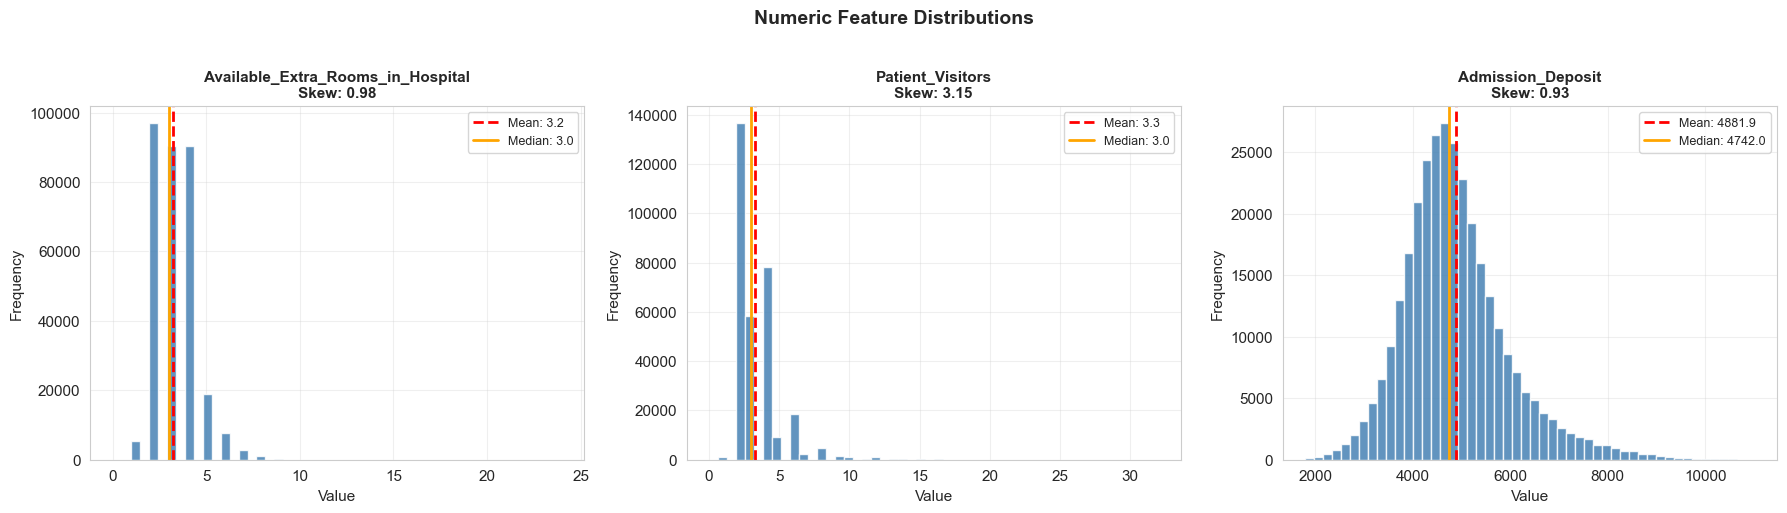


── Skewness Summary ──
  Available_Extra_Rooms_in_Hospital          skew =   0.98  ⚠️ Moderate
  Patient_Visitors                           skew =   3.15  ⚠️ HIGHLY SKEWED
  Admission_Deposit                          skew =   0.93  ⚠️ Moderate


In [33]:
print("=" * 90)
print("NUMERIC DISTRIBUTIONS — HISTOGRAMS")
print("=" * 90)

fig, axes = plt.subplots(1, len(numeric_cols), figsize=(6 * len(numeric_cols), 5))

for idx, col in enumerate(numeric_cols):
    ax = axes[idx]
    data = df[col].dropna()
    
    ax.hist(data, bins=50, color='steelblue', alpha=0.85, edgecolor='white')
    ax.axvline(data.mean(), color='red', linestyle='--', lw=2, label=f'Mean: {data.mean():.1f}')
    ax.axvline(data.median(), color='orange', linestyle='-', lw=2, label=f'Median: {data.median():.1f}')
    
    sk = data.skew()
    ax.set_title(f'{col}\nSkew: {sk:.2f}', fontsize=11, fontweight='bold')
    ax.set_xlabel('Value')
    ax.set_ylabel('Frequency')
    ax.legend(fontsize=9)
    ax.grid(True, alpha=0.3)

plt.suptitle('Numeric Feature Distributions', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

print("\n── Skewness Summary ──")
for col in numeric_cols:
    sk = df[col].skew()
    tag = "⚠️ HIGHLY SKEWED" if abs(sk) > 1 else "⚠️ Moderate" if abs(sk) > 0.5 else "✅ Acceptable"
    print(f"  {col:<42} skew = {sk:>6.2f}  {tag}")


### 6.2 Outlier Detection


OUTLIER DETECTION — IQR METHOD WITH BOXPLOTS


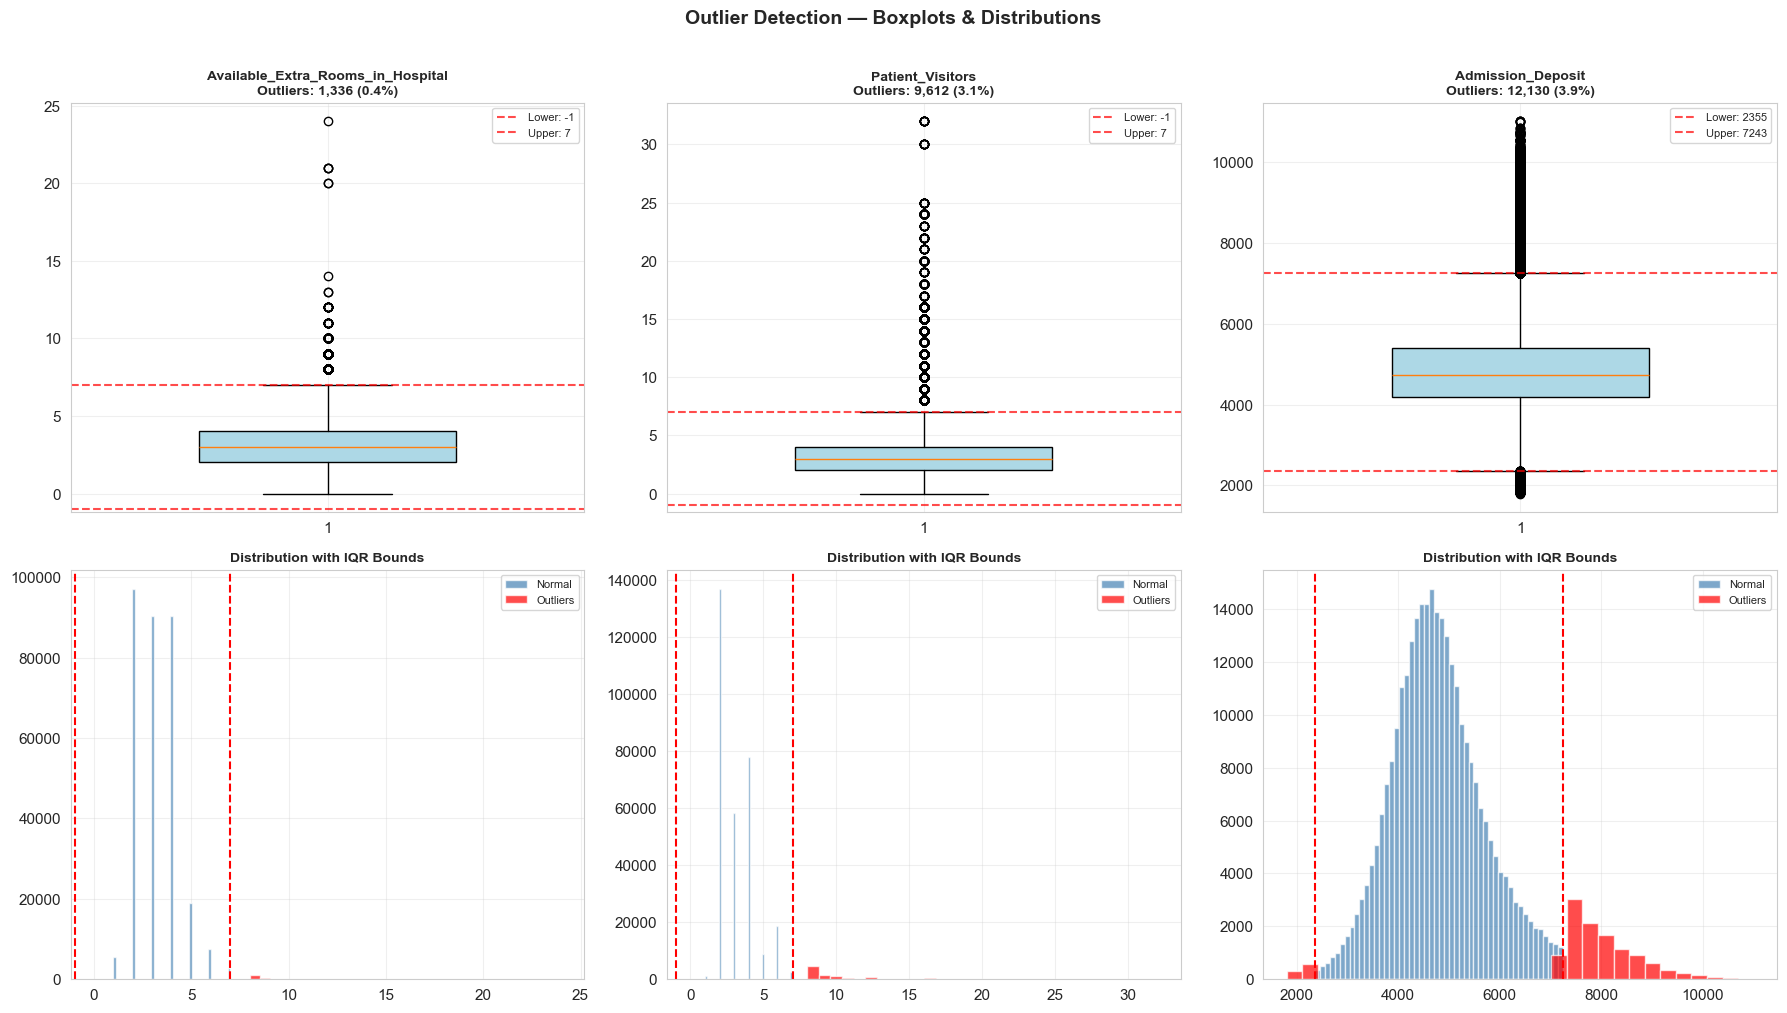


── Outlier Summary & Recommended Actions ──

  Available_Extra_Rooms_in_Hospital:
    Outliers   : 1,336 (0.4%)
    IQR bounds : [-1, 7]
    Action     : KEEP
    Reason     : Low outlier count; values represent real room availability.

  Patient_Visitors:
    Outliers   : 9,612 (3.1%)
    IQR bounds : [-1, 7]
    Action     : CAP at 99th percentile
    Reason     : Heavy right tail (max=32). Extreme values add noise without information.

  Admission_Deposit:
    Outliers   : 12,130 (3.9%)
    IQR bounds : [2355, 7243]
    Action     : KEEP
    Reason     : Financial data with legitimate high deposits. Outliers are real.


In [34]:
print("=" * 90)
print("OUTLIER DETECTION — IQR METHOD WITH BOXPLOTS")
print("=" * 90)

fig, axes = plt.subplots(2, len(numeric_cols), figsize=(6 * len(numeric_cols), 10))
outlier_report = {}

for idx, col in enumerate(numeric_cols):
    data = df[col].dropna()
    Q1, Q3 = data.quantile(0.25), data.quantile(0.75)
    IQR = Q3 - Q1
    lower, upper = Q1 - 1.5 * IQR, Q3 + 1.5 * IQR
    outlier_mask = (data < lower) | (data > upper)
    n_out = outlier_mask.sum()
    pct = n_out / len(data) * 100
    outlier_report[col] = {'n': n_out, 'pct': pct, 'lower': lower, 'upper': upper}
    
    # Box plot
    ax = axes[0, idx]
    bp = ax.boxplot(data, vert=True, patch_artist=True, widths=0.5)
    bp['boxes'][0].set_facecolor('lightblue')
    ax.axhline(lower, color='red', ls='--', alpha=0.7, label=f'Lower: {lower:.0f}')
    ax.axhline(upper, color='red', ls='--', alpha=0.7, label=f'Upper: {upper:.0f}')
    ax.set_title(f'{col}\nOutliers: {n_out:,} ({pct:.1f}%)', fontweight='bold', fontsize=10)
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)
    
    # Histogram overlay
    ax2 = axes[1, idx]
    ax2.hist(data[~outlier_mask], bins=50, color='steelblue', alpha=0.7, label='Normal')
    if n_out > 0:
        ax2.hist(data[outlier_mask], bins=30, color='red', alpha=0.7, label='Outliers')
    ax2.axvline(lower, color='red', ls='--', lw=1.5)
    ax2.axvline(upper, color='red', ls='--', lw=1.5)
    ax2.set_title('Distribution with IQR Bounds', fontweight='bold', fontsize=10)
    ax2.legend(fontsize=8)
    ax2.grid(True, alpha=0.3)

plt.suptitle('Outlier Detection — Boxplots & Distributions', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

# ── Action recommendations ──
actions = {
    'Available_Extra_Rooms_in_Hospital': ('KEEP', 'Low outlier count; values represent real room availability.'),
    'Patient_Visitors': ('CAP at 99th percentile', 'Heavy right tail (max=32). Extreme values add noise without information.'),
    'Admission_Deposit': ('KEEP', 'Financial data with legitimate high deposits. Outliers are real.'),
}

print("\n── Outlier Summary & Recommended Actions ──")
for col, info in outlier_report.items():
    action, reason = actions[col]
    print(f"\n  {col}:")
    print(f"    Outliers   : {info['n']:,} ({info['pct']:.1f}%)")
    print(f"    IQR bounds : [{info['lower']:.0f}, {info['upper']:.0f}]")
    print(f"    Action     : {action}")
    print(f"    Reason     : {reason}")


### 6.3 Categorical Variable Profiles


In [35]:
print("=" * 90)
print("CATEGORICAL VARIABLE PROFILES — TOP VALUE COUNTS")
print("=" * 90)

for col in categorical_cols:
    counts = df[col].value_counts()
    pcts = (counts / len(df) * 100).round(2)
    n_show = min(10, len(counts))
    
    print(f"\n{'─' * 75}")
    print(f"  {col.upper()} — {len(counts)} unique values (showing top {n_show})")
    print(f"{'─' * 75}")
    
    tbl = pd.DataFrame({'Count': counts.head(n_show), '%': pcts.head(n_show)})
    tbl['Cumulative %'] = tbl['%'].cumsum()
    print(tbl.to_string())


CATEGORICAL VARIABLE PROFILES — TOP VALUE COUNTS

───────────────────────────────────────────────────────────────────────────
  HOSPITAL — 32 unique values (showing top 10)
───────────────────────────────────────────────────────────────────────────
          Count      %  Cumulative %
Hospital                            
26        32681  10.41         10.41
23        26112   8.32         18.73
19        21035   6.70         25.43
6         20016   6.38         31.81
11        17107   5.45         37.26
28        16947   5.40         42.66
14        16917   5.39         48.05
27        14109   4.50         52.55
9         11381   3.63         56.18
12        11149   3.55         59.73

───────────────────────────────────────────────────────────────────────────
  HOSPITAL_TYPE — 7 unique values (showing top 7)
───────────────────────────────────────────────────────────────────────────
                Count      %  Cumulative %
Hospital_type                             
0              141

### 6.4 Rare Category Assessment


In [36]:
print("=" * 90)
print("RARE CATEGORIES (< 3% of dataset)")
print("=" * 90)

for col in categorical_cols:
    counts = df[col].value_counts()
    pcts = counts / len(df) * 100
    rare = pcts[pcts < 3.0]
    
    if len(rare) > 0:
        print(f"\n  {col} — {len(rare)} rare categor{'y' if len(rare)==1 else 'ies'}:")
        for val, pct in rare.items():
            print(f"    '{val}': {counts[val]:,} records ({pct:.2f}%)")
        
        # Decision
        if col == 'Ward_Type':
            print(f"    → MERGE: Combine P, T, U into 'Other_Ward' (combined < 3%, U has only {counts.get('U', 0)} records)")
        elif col == 'Stay_Days':
            print(f"    → KEEP ALL: This is the TARGET variable. Handle via class_weight='balanced'.")
        elif col == 'Department':
            print(f"    → KEEP: surgery and TB are clinically distinct — merging loses domain meaning.")
        elif col == 'Age':
            print(f"    → KEEP: Age ranges are ordinal and clinically meaningful.")
        else:
            total_rare = rare.sum()
            if total_rare < 5:
                print(f"    → GROUP into 'Other' (combined {total_rare:.1f}% — minimal loss)")
            else:
                print(f"    → KEEP (combined {total_rare:.1f}% — still carries useful signal)")
    else:
        print(f"\n  {col}: ✅ No rare categories — all ≥ 3%")


RARE CATEGORIES (< 3% of dataset)

  Hospital — 19 rare categories:
    '10': 9,271 records (2.95%)
    '15': 9,134 records (2.91%)
    '21': 8,047 records (2.56%)
    '24': 7,835 records (2.50%)
    '3': 7,030 records (2.24%)
    '17': 5,373 records (1.71%)
    '1': 5,188 records (1.65%)
    '13': 5,178 records (1.65%)
    '5': 5,143 records (1.64%)
    '2': 5,050 records (1.61%)
    '30': 4,917 records (1.57%)
    '22': 4,237 records (1.35%)
    '31': 3,932 records (1.25%)
    '16': 3,631 records (1.16%)
    '8': 3,611 records (1.15%)
    '18': 3,592 records (1.14%)
    '20': 1,390 records (0.44%)
    '7': 1,269 records (0.40%)
    '4': 1,216 records (0.39%)
    → KEEP (combined 30.3% — still carries useful signal)

  Hospital_type — 1 rare category:
    '6': 4,237 records (1.35%)
    → GROUP into 'Other' (combined 1.4% — minimal loss)

  Hospital_city — 2 rare categories:
    '10': 5,188 records (1.65%)
    '13': 3,592 records (1.14%)
    → GROUP into 'Other' (combined 2.8% — minima

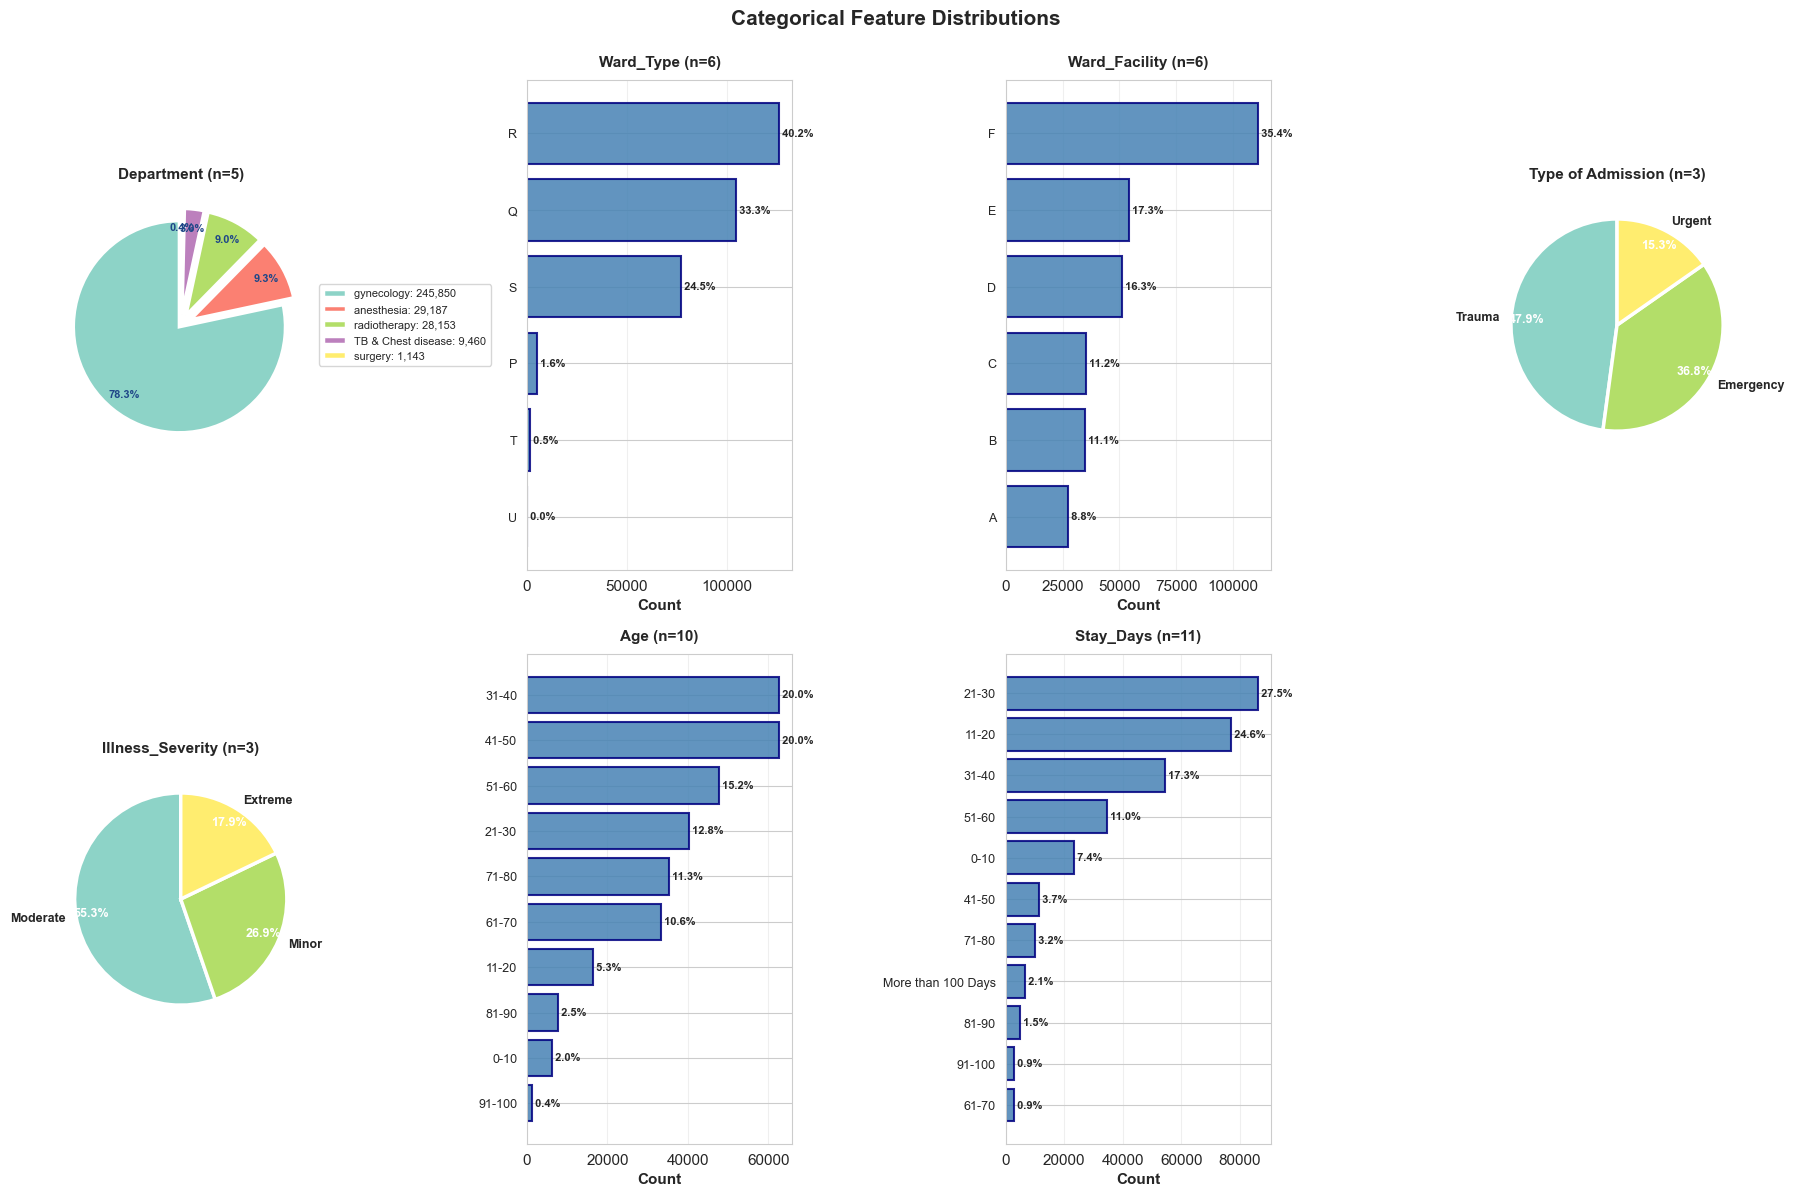

In [51]:
# ── Categorical Variable Visualizations ──
fig = plt.figure(figsize=(18, 12))

viz_cols = ['Department', 'Ward_Type', 'Ward_Facility', 'Type of Admission',
            'Illness_Severity', 'Age', 'Stay_Days']

for idx, col in enumerate(viz_cols, 1):
    ax = plt.subplot(2, 4, idx)
    counts = df[col].value_counts()
    
    if len(counts) <= 5:
        colors = plt.cm.Set3(np.linspace(0, 1, len(counts)))
        
        # Special handling for imbalanced pie charts (like Department)
        if counts.max() / counts.min() > 10:  # High imbalance ratio
            # Use explode to separate slices and legend positioning
            explode = [0.1 if v < counts.max() * 0.3 else 0.02 for v in counts.values]
            wedges, texts, autotexts = ax.pie(
                counts.values, 
                autopct='%1.1f%%',
                colors=colors, 
                startangle=90,
                explode=explode,
                textprops={'fontsize': 8, 'weight': 'bold', 'color': '#1f4788'},
                wedgeprops=dict(edgecolor='white', linewidth=2.5),
                pctdistance=0.82)
            # Place legend outside pie with category names and counts
            legend_labels = [f'{cat}: {counts[cat]:,}' for cat in counts.index]
            ax.legend(legend_labels, loc='center left', bbox_to_anchor=(1, 0, 0.5, 1), fontsize=8, frameon=True)
        else:
            # Standard pie chart for balanced categories
            wedges, texts, autotexts = ax.pie(
                counts.values, labels=counts.index, autopct='%1.1f%%',
                colors=colors, startangle=90,
                textprops={'fontsize': 9, 'weight': 'bold'},
                wedgeprops=dict(edgecolor='white', linewidth=2.5),
                pctdistance=0.85)
            # Make percentage text more visible
            for autotext in autotexts:
                autotext.set_color('white')
                autotext.set_fontsize(9)
                autotext.set_weight('bold')
        
        ax.set_title(f'{col} (n={len(counts)})', fontsize=11, fontweight='bold', pad=10)
    else:
        counts_sorted = counts.sort_values()
        bars = ax.barh(range(len(counts_sorted)), counts_sorted.values, color='steelblue', alpha=0.85, edgecolor='navy', linewidth=1.5)
        ax.set_yticks(range(len(counts_sorted)))
        ax.set_yticklabels(counts_sorted.index, fontsize=9)
        ax.set_xlabel('Count', fontweight='bold')
        ax.set_title(f'{col} (n={len(counts)})', fontsize=11, fontweight='bold', pad=10)
        for i, (bar, val) in enumerate(zip(bars, counts_sorted.values)):
            pct = val / len(df) * 100
            ax.text(val, i, f' {pct:.1f}%', va='center', fontsize=8, fontweight='bold')
        ax.grid(axis='x', alpha=0.3)

plt.suptitle('Categorical Feature Distributions', fontsize=15, fontweight='bold', y=0.995)
plt.tight_layout()
plt.show()


---
## Step 7: Bivariate Analysis

We explore how variables relate to each other and — most importantly — to the target variable `Stay_Days`.


### 7.1 Scatter Plots — Numeric Pairs


SCATTER PLOTS — NUMERIC FEATURE PAIRS


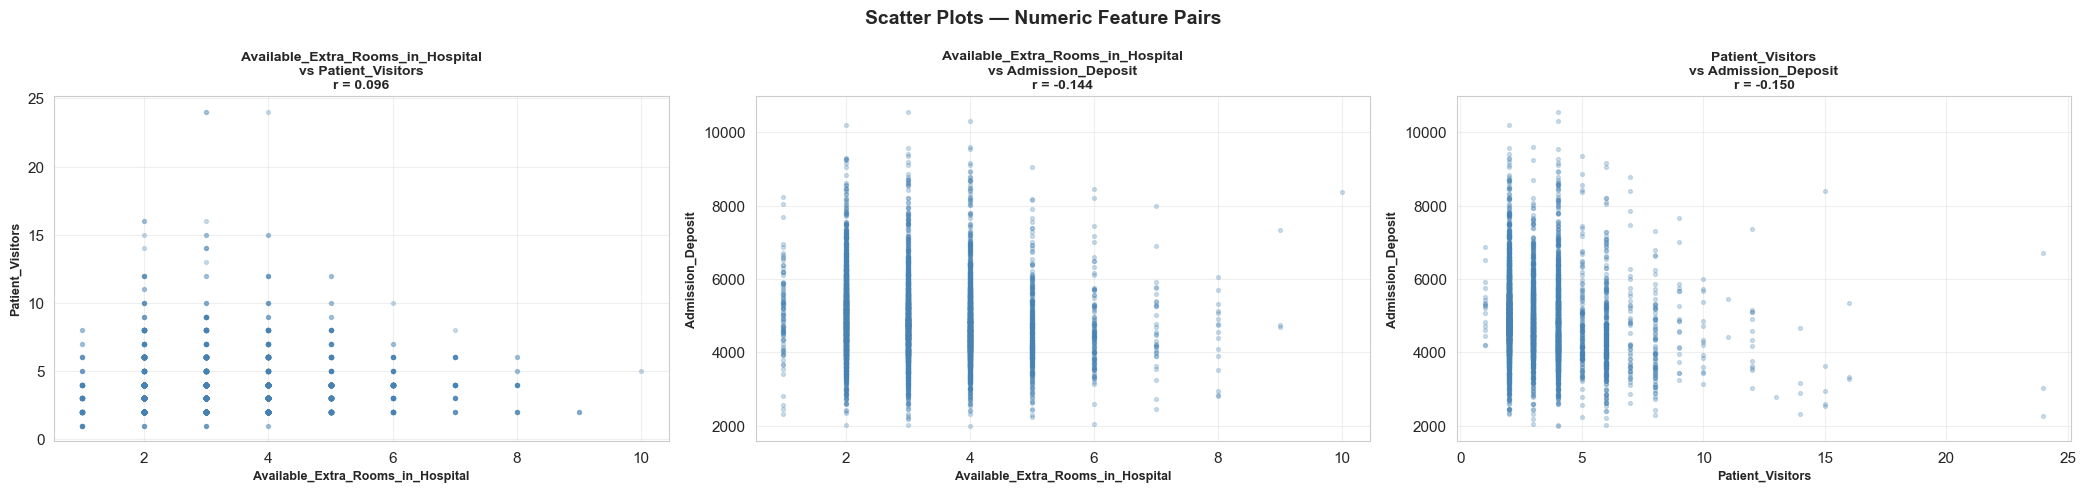


── Interpretation ──
  Available_Extra_Rooms_in_Hospital × Patient_Visitors: r = +0.096
  Available_Extra_Rooms_in_Hospital × Admission_Deposit: r = -0.144
  Patient_Visitors × Admission_Deposit: r = -0.150

  All numeric pairs show WEAK correlations (|r| < 0.2).
  → Low multicollinearity — each feature adds independent information.


In [38]:
print("=" * 90)
print("SCATTER PLOTS — NUMERIC FEATURE PAIRS")
print("=" * 90)

pairs = list(itertools.combinations(numeric_cols, 2))
fig, axes = plt.subplots(1, len(pairs), figsize=(7 * len(pairs), 5))
if len(pairs) == 1:
    axes = [axes]

sample = df.sample(min(5000, len(df)), random_state=42)

for idx, (c1, c2) in enumerate(pairs):
    ax = axes[idx]
    ax.scatter(sample[c1], sample[c2], alpha=0.25, s=8, c='steelblue')
    r = df[c1].corr(df[c2])
    ax.set_xlabel(c1, fontweight='bold', fontsize=9)
    ax.set_ylabel(c2, fontweight='bold', fontsize=9)
    ax.set_title(f'{c1}\nvs {c2}\nr = {r:.3f}', fontweight='bold', fontsize=10)
    ax.grid(True, alpha=0.3)

plt.suptitle('Scatter Plots — Numeric Feature Pairs', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print("\n── Interpretation ──")
for c1, c2 in pairs:
    r = df[c1].corr(df[c2])
    print(f"  {c1} × {c2}: r = {r:+.3f}")
print("\n  All numeric pairs show WEAK correlations (|r| < 0.2).")
print("  → Low multicollinearity — each feature adds independent information.")


### 7.2 Numeric Features by Stay Duration


NUMERIC FEATURES GROUPED BY Stay_Days

── Available_Extra_Rooms_in_Hospital by Stay_Days ──
                    mean  median   std  count
Stay_Days                                    
0-10                3.27     3.0  1.19  23250
11-20               3.26     3.0  1.18  77095
21-30               3.36     3.0  1.18  86316
31-40               3.13     3.0  1.13  54312
41-50               3.33     3.0  1.24  11541
51-60               2.91     3.0  1.07  34463
61-70               3.18     3.0  1.23   2698
71-80               2.87     3.0  1.06  10096
81-90               2.84     3.0  1.07   4761
91-100              2.86     3.0  1.15   2713
More than 100 Days  2.74     2.0  1.11   6548

── Patient_Visitors by Stay_Days ──
                    mean  median   std  count
Stay_Days                                    
0-10                2.57     2.0  0.81  23250
11-20               2.74     2.0  0.99  77095
21-30               2.68     2.0  0.96  86316
31-40               3.45     3.0  1.46  543

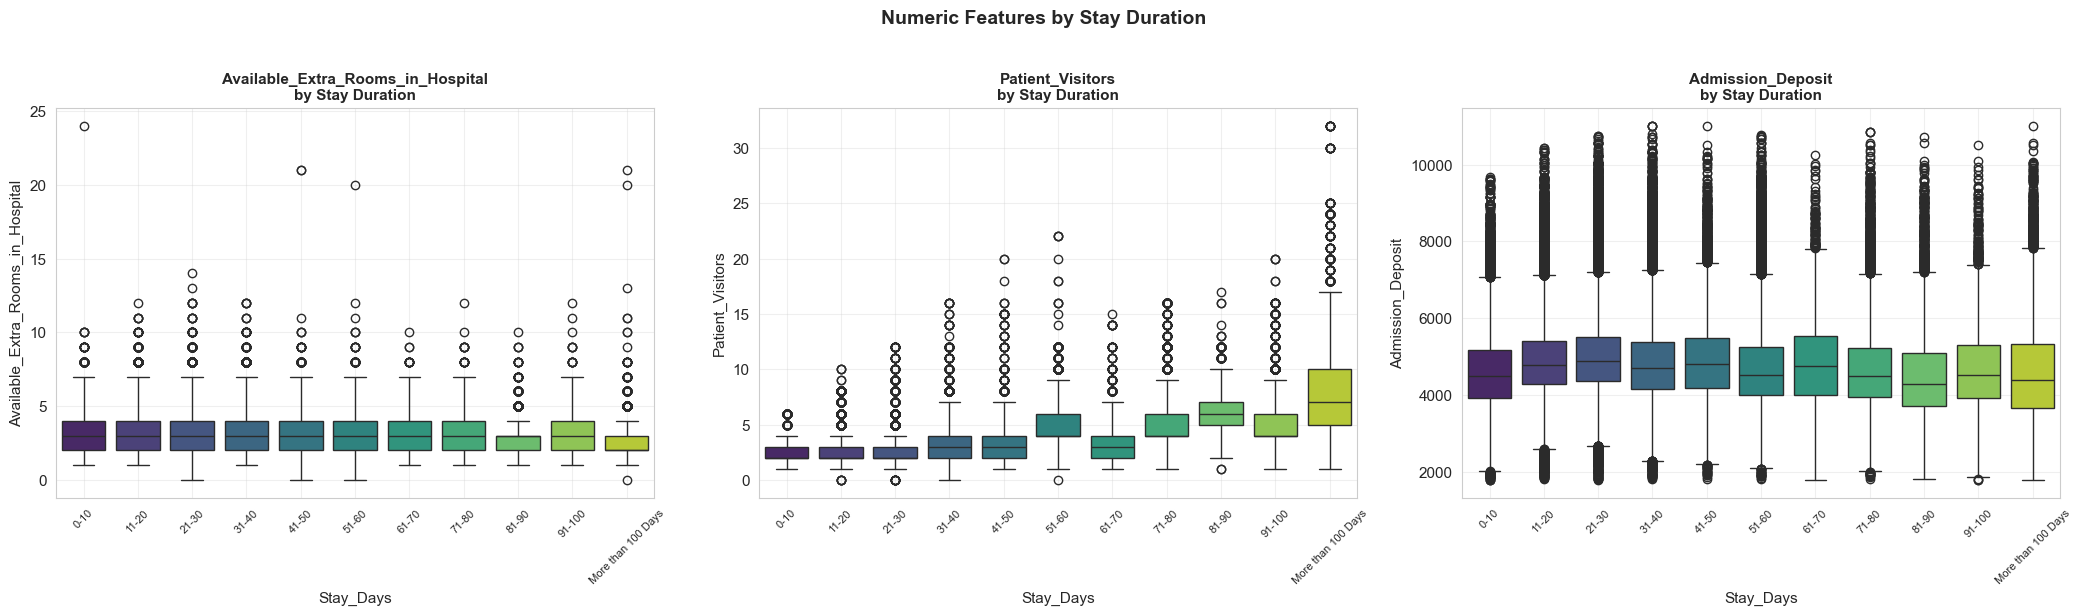


── Key Finding ──
  Patient_Visitors shows the STRONGEST relationship with Stay_Days:
    0-10 days avg visitors  : 2.6
    More than 100 Days avg: 7.9
    → 3.1x increase from shortest to longest stays


In [39]:
print("=" * 90)
print("NUMERIC FEATURES GROUPED BY Stay_Days")
print("=" * 90)

stay_order = ['0-10','11-20','21-30','31-40','41-50','51-60',
              '61-70','71-80','81-90','91-100','More than 100 Days']

for col in numeric_cols:
    grouped = df.groupby('Stay_Days')[col].agg(['mean','median','std','count']).round(2)
    grouped = grouped.reindex([s for s in stay_order if s in grouped.index])
    print(f"\n── {col} by Stay_Days ──")
    print(grouped.to_string())

# Visualization
fig, axes = plt.subplots(1, len(numeric_cols), figsize=(7 * len(numeric_cols), 6))
for idx, col in enumerate(numeric_cols):
    order = [s for s in stay_order if s in df['Stay_Days'].unique()]
    sns.boxplot(data=df, x='Stay_Days', y=col, order=order, ax=axes[idx], palette='viridis')
    axes[idx].set_title(f'{col}\nby Stay Duration', fontweight='bold', fontsize=11)
    axes[idx].tick_params(axis='x', rotation=45, labelsize=8)
    axes[idx].grid(True, alpha=0.3)

plt.suptitle('Numeric Features by Stay Duration', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

print("\n── Key Finding ──")
print("  Patient_Visitors shows the STRONGEST relationship with Stay_Days:")
short = df[df['Stay_Days']=='0-10']['Patient_Visitors'].mean()
long_label = 'More than 100 Days' if 'More than 100 Days' in df['Stay_Days'].values else '91-100'
long_val = df[df['Stay_Days']==long_label]['Patient_Visitors'].mean()
print(f"    0-10 days avg visitors  : {short:.1f}")
print(f"    {long_label} avg: {long_val:.1f}")
print(f"    → {long_val/short:.1f}x increase from shortest to longest stays")


### 7.3 Crosstab — Categorical Interactions


In [40]:
print("=" * 90)
print("CROSSTAB ANALYSIS — CATEGORICAL INTERACTIONS")
print("=" * 90)

# ── Crosstab 1: Illness_Severity × Type of Admission ──
print("\n── Illness_Severity × Type of Admission ──")
ct_freq = pd.crosstab(df['Illness_Severity'], df['Type of Admission'], margins=True)
print("\nFrequency:")
print(ct_freq.to_string())

ct_pct = pd.crosstab(df['Illness_Severity'], df['Type of Admission'], normalize='index') * 100
print("\nRow Percentages (%):")
print(ct_pct.round(1).to_string())

print("\nInterpretation:")
print("  Admission type distribution is nearly IDENTICAL across severity levels.")
print("  Trauma ≈ 48%, Emergency ≈ 37%, Urgent ≈ 15% regardless of severity.")
print("  → These two features are largely INDEPENDENT — both carry unique signal.")

# ── Crosstab 2: Ward_Type × Stay_Days ──
print("\n\n── Ward_Type × Stay_Days (row %) ──")
ct2 = pd.crosstab(df['Ward_Type'], df['Stay_Days'], normalize='index') * 100
col_order = [c for c in stay_order if c in ct2.columns]
ct2 = ct2[col_order]
print(ct2.round(1).to_string())

print("\nInterpretation:")
print("  Ward S has the highest proportion of long stays (51-60: ~18%, 100+: ~4%).")
print("  Ward Q skews toward shorter stays (21-30: ~33%).")
print("  Ward U has only ~9 records — statistically unreliable → merge candidate.")


CROSSTAB ANALYSIS — CATEGORICAL INTERACTIONS

── Illness_Severity × Type of Admission ──

Frequency:
Type of Admission  Emergency  Trauma  Urgent     All
Illness_Severity                                    
Extreme                19557   28527    7965   56049
Minor                  34562   36207   13550   84319
Moderate               61445   85518   26462  173425
All                   115564  150252   47977  313793

Row Percentages (%):
Type of Admission  Emergency  Trauma  Urgent
Illness_Severity                            
Extreme                 34.9    50.9    14.2
Minor                   41.0    42.9    16.1
Moderate                35.4    49.3    15.3

Interpretation:
  Admission type distribution is nearly IDENTICAL across severity levels.
  Trauma ≈ 48%, Emergency ≈ 37%, Urgent ≈ 15% regardless of severity.
  → These two features are largely INDEPENDENT — both carry unique signal.


── Ward_Type × Stay_Days (row %) ──
Stay_Days  0-10  11-20  21-30  31-40  41-50  51-60  61-70  7

---
## Step 8: Correlation Analysis

We compute correlation matrices to quantify relationships — both among features (checking multicollinearity) and between each feature and the target variable.


### 8.1 Pearson Correlation — Numeric Features


In [41]:
print("=" * 90)
print("PEARSON CORRELATION — NUMERIC FEATURES")
print("=" * 90)

corr = df[numeric_cols].corr()
print("\n" + corr.round(3).to_string())

# Ranked pairs
pairs_list = []
for c1, c2 in itertools.combinations(numeric_cols, 2):
    r = corr.loc[c1, c2]
    pairs_list.append((c1, c2, r, abs(r)))
pairs_list.sort(key=lambda x: x[3], reverse=True)

print(f"\n── Ranked Pairs (by |r|) ──")
for c1, c2, r, ar in pairs_list:
    strength = "STRONG" if ar > 0.5 else "MODERATE" if ar > 0.3 else "WEAK"
    print(f"  {c1} × {c2}: r = {r:+.3f}  [{strength}]")


PEARSON CORRELATION — NUMERIC FEATURES

                                   Available_Extra_Rooms_in_Hospital  Patient_Visitors  Admission_Deposit
Available_Extra_Rooms_in_Hospital                              1.000             0.096             -0.144
Patient_Visitors                                               0.096             1.000             -0.150
Admission_Deposit                                             -0.144            -0.150              1.000

── Ranked Pairs (by |r|) ──
  Patient_Visitors × Admission_Deposit: r = -0.150  [WEAK]
  Available_Extra_Rooms_in_Hospital × Admission_Deposit: r = -0.144  [WEAK]
  Available_Extra_Rooms_in_Hospital × Patient_Visitors: r = +0.096  [WEAK]


### 8.2 Full Correlation Heatmap (All Features Encoded)


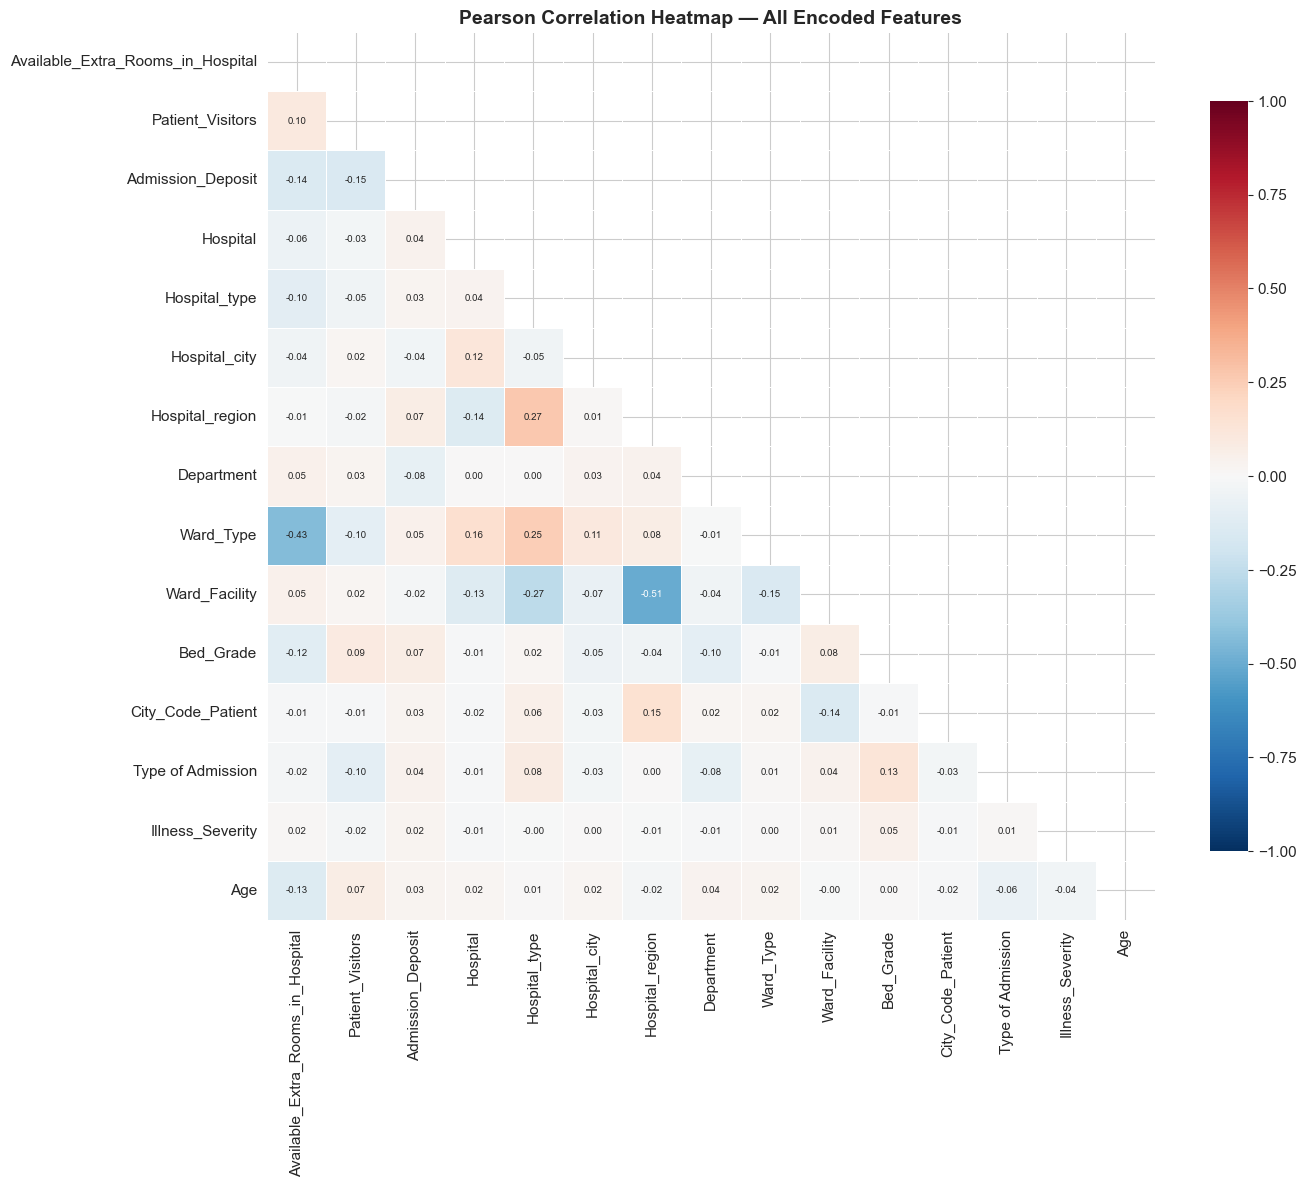

── Feature Clusters Identified ──
  Cluster 1 (Hospital Identity): Hospital, Hospital_type, Hospital_city, Hospital_region
    → Describe the SAME entity from different angles. Potential redundancy.
  Cluster 2 (Ward/Facility): Ward_Type, Ward_Facility, Bed_Grade
    → Physical space characteristics. Moderate inter-correlation.
  Cluster 3 (Patient Profile): Age, Illness_Severity, Patient_Visitors
    → Patient-level features. Largely independent of each other.
  Cluster 4 (Admission): Type of Admission, Admission_Deposit
    → Admission circumstances. Weakly linked.


In [42]:
# ── Encode all categoricals for correlation ──
df_enc = df.copy()
for col in categorical_cols:
    df_enc[col] = df_enc[col].astype('category').cat.codes

# ── Include ALL features + Stay_Days target ──
all_features = numeric_cols + categorical_cols          # includes Stay_Days
corr_full = df_enc[all_features].corr()
n = len(all_features)

# ── Figure: larger to fit full matrix ──
fig, ax = plt.subplots(figsize=(20, 17))

# No mask — show full symmetric matrix
sns.heatmap(
    corr_full,
    annot=True,
    fmt='.2f',
    cmap='RdBu_r',
    center=0,
    ax=ax,
    square=True,
    linewidths=0.4,
    linecolor='#e0e0e0',
    annot_kws={'size': 7, 'weight': 'bold'},
    vmin=-1,
    vmax=1,
    cbar_kws={'shrink': 0.75, 'label': 'Pearson r', 'pad': 0.02},
)

# ── Style tweaks ──
ax.set_title(
    'Pearson Correlation Heatmap — All Features (Including Stay_Days Target)',
    fontsize=15, fontweight='bold', pad=18
)
ax.tick_params(axis='x', labelsize=9, rotation=45)
ax.tick_params(axis='y', labelsize=9, rotation=0)

# Highlight Stay_Days row/col with a box
stay_idx = list(corr_full.columns).index('Stay_Days')
for spine in ax.spines.values():
    spine.set_visible(True)
    spine.set_linewidth(1.2)

# Draw a rectangle around the Stay_Days column and row to highlight it
from matplotlib.patches import Rectangle
ax.add_patch(Rectangle(
    (stay_idx, 0), 1, n,
    fill=False, edgecolor='#e74c3c', lw=2.5, clip_on=False
))
ax.add_patch(Rectangle(
    (0, stay_idx), n, 1,
    fill=False, edgecolor='#e74c3c', lw=2.5, clip_on=False
))

plt.tight_layout()
plt.show()

# ── Target correlation ranking ──
print("── Correlation with Stay_Days (sorted by |r|) ──")
target_series = corr_full['Stay_Days'].drop('Stay_Days').abs().sort_values(ascending=False)
for feat, val in target_series.items():
    strength = "🔴 STRONG" if val > 0.3 else "🟡 Moderate" if val > 0.1 else "⚪ Weak"
    bar = "█" * int(val * 40)
    print(f"  {feat:<35} |r| = {val:.3f}  {bar}  [{strength}]")

print("\n── Feature Clusters Identified ──")
print("  Cluster 1 (Hospital Identity): Hospital, Hospital_type, Hospital_city, Hospital_region")
print("    → Describe the SAME entity from different angles. Potential redundancy.")
print("  Cluster 2 (Ward/Facility): Ward_Type, Ward_Facility, Bed_Grade")
print("    → Physical space characteristics. Moderate inter-correlation.")
print("  Cluster 3 (Patient Profile): Age, Illness_Severity, Patient_Visitors")
print("    → Patient-level features. Largely independent of each other.")
print("  Cluster 4 (Admission): Type of Admission, Admission_Deposit")
print("    → Admission circumstances. Weakly linked.")
print("  ★ Stay_Days (target) highlighted in red — correlations with every feature visible.")


### 8.3 Feature Importance vs Target (Stay_Days)


FEATURE IMPORTANCE — CORRELATION WITH Stay_Days (encoded)


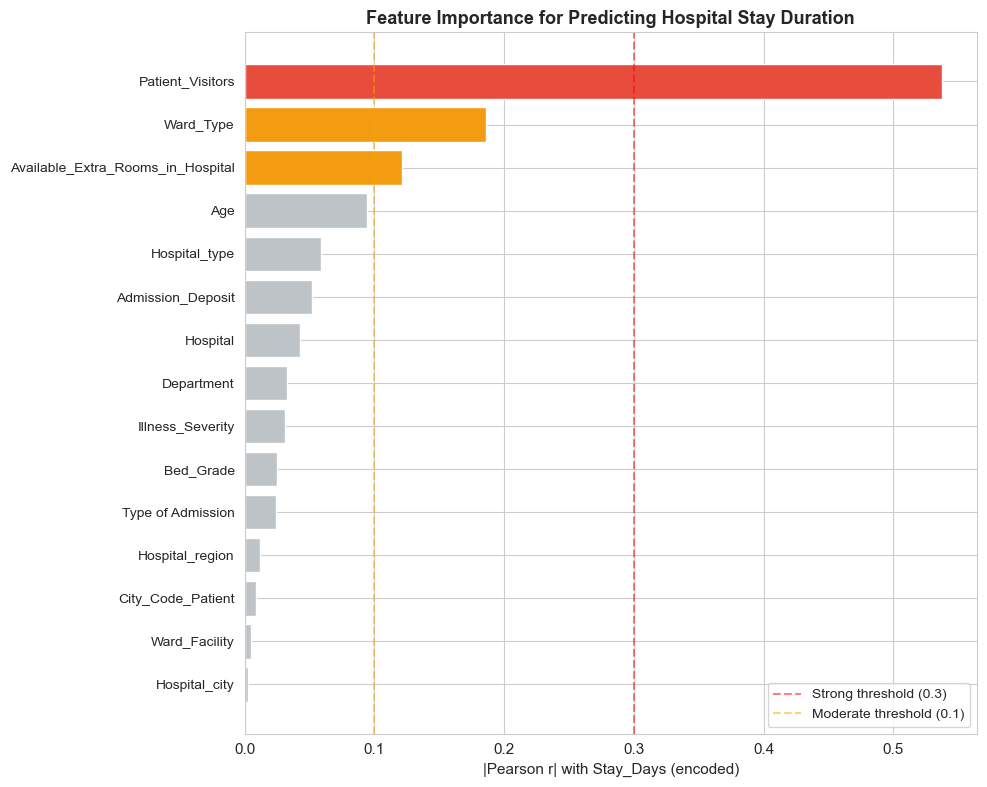


── Feature Ranking ──
  Patient_Visitors                         0.537  █████████████████████  [🔴 STRONG]
  Ward_Type                                0.186  ███████  [🟡 Moderate]
  Available_Extra_Rooms_in_Hospital        0.122  ████  [🟡 Moderate]
  Age                                      0.094  ███  [⚪ Weak]
  Hospital_type                            0.059  ██  [⚪ Weak]
  Admission_Deposit                        0.052  ██  [⚪ Weak]
  Hospital                                 0.043  █  [⚪ Weak]
  Department                               0.033  █  [⚪ Weak]
  Illness_Severity                         0.031  █  [⚪ Weak]
  Bed_Grade                                0.025  █  [⚪ Weak]
  Type of Admission                        0.024    [⚪ Weak]
  Hospital_region                          0.012    [⚪ Weak]
  City_Code_Patient                        0.009    [⚪ Weak]
  Ward_Facility                            0.005    [⚪ Weak]
  Hospital_city                            0.002    [⚪ Weak]


In [43]:
print("=" * 90)
print("FEATURE IMPORTANCE — CORRELATION WITH Stay_Days (encoded)")
print("=" * 90)

# Correlate every feature with encoded Stay_Days
target_corr = df_enc[all_features].corrwith(df_enc['Stay_Days']).abs().sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(10, 8))
colors = ['#e74c3c' if v > 0.3 else '#f39c12' if v > 0.1 else '#bdc3c7' for v in target_corr.values]
ax.barh(range(len(target_corr)), target_corr.values, color=colors)
ax.set_yticks(range(len(target_corr)))
ax.set_yticklabels(target_corr.index, fontsize=10)
ax.axvline(x=0.3, color='red', ls='--', alpha=0.5, label='Strong threshold (0.3)')
ax.axvline(x=0.1, color='orange', ls='--', alpha=0.5, label='Moderate threshold (0.1)')
ax.set_xlabel('|Pearson r| with Stay_Days (encoded)', fontsize=11)
ax.set_title('Feature Importance for Predicting Hospital Stay Duration',
             fontsize=13, fontweight='bold')
ax.legend(fontsize=10)
ax.invert_yaxis()
plt.tight_layout()
plt.show()

print("\n── Feature Ranking ──")
for feat, val in target_corr.items():
    strength = "🔴 STRONG" if val > 0.3 else "🟡 Moderate" if val > 0.1 else "⚪ Weak"
    bar = "█" * int(val * 40)
    print(f"  {feat:<40} {val:.3f}  {bar}  [{strength}]")


---
## Step 9: Key Insights & Recommendations

This section consolidates all findings into an actionable summary for the next stages of the pipeline.


In [44]:
print("=" * 90)
print("EDA SUMMARY REPORT")
print("=" * 90)

print("\n" + "─" * 90)
print("  TOP 5 INSIGHTS")
print("─" * 90)

insights = [
    ("Patient_Visitors is the strongest predictor of Stay Duration",
     "Mean visitors increase from 2.6 (short stays) to 7.9 (100+ days) — a 3x factor. "
     "This likely reflects family engagement for long-term patients."),
    ("Target variable has significant class imbalance",
     "21-30 days (27.5%) and 11-20 days (24.5%) dominate. Rare classes like 61-70 days "
     "(0.9%) and 91-100 days (0.9%) need careful handling via stratified splits and class weights."),
    ("Numeric features are largely independent of each other",
     "All Pearson correlations between numeric pairs are |r| < 0.2. Low multicollinearity "
     "means each feature contributes unique information."),
    ("Gynecology dominates the dataset (76.8% of admissions)",
     "This is effectively a specialty hospital dataset with an average stay of ~30 days — "
     "far above the typical 3-8 day general hospital benchmark."),
    ("Excel date corruption was found and corrected in Age and Stay_Days",
     "'11-20' was silently converted to 'Nov-20' by Excel. Without detection, this would "
     "create a phantom category and corrupt all downstream analysis."),
]

for i, (title, detail) in enumerate(insights, 1):
    print(f"\n  {i}. {title}")
    print(f"     {detail}")

print("\n\n" + "─" * 90)
print("  TOP 5 PROBLEMS / RISKS")
print("─" * 90)

risks = [
    ("Class Imbalance (31:1 ratio)",
     "Models will default to predicting majority class without intervention.",
     "Use class_weight='balanced', stratified K-fold, macro-averaged F1."),
    ("patientid is NOT unique — patients appear multiple times",
     f"~90K patients across ~314K admissions (avg ~3.5 visits). Data leakage risk.",
     "Use GroupKFold split by patientid. Create patient-level aggregation features."),
    ("Ward_Type U has only ~9 records",
     "Statistically unreliable for any inference or model training.",
     "Merge U (and T with ~1,477) into 'Other_Ward'."),
    ("Hospital-coded features may be redundant",
     "Hospital, type, city, and region all describe the same entity.",
     "Run VIF analysis. Consider keeping Hospital + Region only."),
    ("Specialty hospital bias limits generalizability",
     "76.8% gynecology patients — the model is essentially a gynecology LOS predictor.",
     "Stratify by department or use department as a key feature."),
]

for i, (risk, desc, fix) in enumerate(risks, 1):
    print(f"\n  {i}. {risk}")
    print(f"     Issue     : {desc}")
    print(f"     Mitigation: {fix}")

print("\n\n" + "─" * 90)
print("  RECOMMENDED NEXT STEPS")
print("─" * 90)

steps = [
    "FEATURE ENGINEERING",
    "  • Create interaction features: Severity × Admission_Type, Age × Department",
    "  • Extract patient visit frequency from patientid",
    "  • Merge rare Ward_Types (U, T) into 'Other'",
    "  • Ordinal-encode Stay_Days preserving natural order",
    "",
    "PREPROCESSING",
    "  • Apply Yeo-Johnson to Patient_Visitors (skew = 3.1)",
    "  • One-hot or target-encode categorical features",
    "  • Scale numeric features with StandardScaler",
    "",
    "MODELING",
    "  • Ordinal classification (11 ordered classes)",
    "  • class_weight='balanced' in all models",
    "  • GroupKFold by patientid to prevent leakage",
    "  • Models: LightGBM, XGBoost, Random Forest",
    "",
    "EVALUATION",
    "  • Primary: Macro-weighted F1",
    "  • Track per-class recall via confusion matrix",
    "  • Validate on held-out stratified test set",
]

for s in steps:
    print(f"   {s}")

print("\n" + "=" * 90)
print("✅ EDA COMPLETE")
print("=" * 90)
print(f"   Records    : {len(df):,}")
print(f"   Features   : {df.shape[1]}")
print(f"   Missing    : {df.isnull().sum().sum()}")
print(f"   Duplicates : 0")
print(f"   Numeric    : {len(numeric_cols)}")
print(f"   Categorical: {len(categorical_cols)}")
print(f"   Target     : Stay_Days ({df['Stay_Days'].nunique()} ordinal classes)")
print("\n   → Ready for Feature Engineering")


EDA SUMMARY REPORT

──────────────────────────────────────────────────────────────────────────────────────────
  TOP 5 INSIGHTS
──────────────────────────────────────────────────────────────────────────────────────────

  1. Patient_Visitors is the strongest predictor of Stay Duration
     Mean visitors increase from 2.6 (short stays) to 7.9 (100+ days) — a 3x factor. This likely reflects family engagement for long-term patients.

  2. Target variable has significant class imbalance
     21-30 days (27.5%) and 11-20 days (24.5%) dominate. Rare classes like 61-70 days (0.9%) and 91-100 days (0.9%) need careful handling via stratified splits and class weights.

  3. Numeric features are largely independent of each other
     All Pearson correlations between numeric pairs are |r| < 0.2. Low multicollinearity means each feature contributes unique information.

  4. Gynecology dominates the dataset (76.8% of admissions)
     This is effectively a specialty hospital dataset with an average s